# Data Cleaning Pipeline - Tối ưu cho xử lý giá trị thiếu và ngoại lai

## Sử dụng DataCleaner class với cách tiếp cận đồng bộ: NaN = Missing = "None"


### 1. Import và Load Data


In [209]:
# Import libraries
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('../src'))
from eda.eda import EDA
# Import DataCleaner class
from preprocess.clean.clean import DataCleaner, clean_data, handle_missing_values, handle_outliers

# Load data
train_df = pd.read_csv('../data/raw/train.csv')
test_df=pd.read_csv('../data/raw/test.csv')
print(f"Original train data shape: {train_df.shape}")
print(f"Missing values: {train_df.isnull().sum().sum()}")
print(f"Duplicates: {train_df.duplicated().sum()}")


Original train data shape: (1460, 81)
Missing values: 7829
Duplicates: 0


Gộp train test

### 2. Khởi tạo DataCleaner


In [210]:
# Khởi tạo DataCleaner với cách tiếp cận tối ưu
cleaner = DataCleaner(train_df)
eda=EDA(train_df)
print("✅ Đã khởi tạo DataCleaner")
print("🎯 Chiến lược: NaN = Missing = 'None'")
print("📊 Ngưỡng drop column: 30%")


✅ Đã khởi tạo DataCleaner
🎯 Chiến lược: NaN = Missing = 'None'
📊 Ngưỡng drop column: 30%


### 3. Phân tích giá trị thiếu (Before Cleaning)


In [211]:
# Phân tích chi tiết giá trị thiếu TRƯỚC khi clean
print("📊 PHÂN TÍCH GIÁ TRỊ THIẾU TRƯỚC KHI CLEAN:")


eda.missing_values()





📊 PHÂN TÍCH GIÁ TRỊ THIẾU TRƯỚC KHI CLEAN:


## 🔍 Phân Tích Giá Trị Thiếu

**📉 Các cột có giá trị thiếu**

,Cột,Số lượng thiếu,% thiếu
72,PoolQC,1453,99.520000
74,MiscFeature,1406,96.300000
6,Alley,1369,93.770000
73,Fence,1179,80.750000
25,MasVnrType,872,59.730000
57,FireplaceQu,690,47.260000
3,LotFrontage,259,17.740000
58,GarageType,81,5.550000
59,GarageYrBlt,81,5.550000
60,GarageFinish,81,5.550000


### 4. Xử lý giá trị thiếu với chiến lược tối ưu


In [212]:
# Xử lý giá trị thiếu với chiến lược tối ưu
print("🚀 BẮT ĐẦU XỬ LÝ GIÁ TRỊ THIẾU:")
print("=" * 50)

# Sử dụng strategy "none" với threshold 30%




🚀 BẮT ĐẦU XỬ LÝ GIÁ TRỊ THIẾU:


In [213]:
#check the numbers of samples and features
print("The train data size before dropping Id feature is : {} ".format(train_df.shape))
print("The test data size before dropping Id feature is : {} ".format(test_df.shape))

#Save the 'Id' column
train_ID = train_df['Id']
test_ID = test_df['Id']

#Now drop the  'Id' colum since it's unnecessary for  the prediction process.
train_df.drop("Id", axis = 1, inplace = True)
test_df.drop("Id", axis = 1, inplace = True)

#check again the data size after dropping the 'Id' variable
print("\nThe train data size after dropping Id feature is : {} ".format(train_df.shape)) 
print("The test data size after dropping Id feature is : {} ".format(test_df.shape))

The train data size before dropping Id feature is : (1460, 81) 
The test data size before dropping Id feature is : (1459, 80) 

The train data size after dropping Id feature is : (1460, 80) 
The test data size after dropping Id feature is : (1459, 79) 


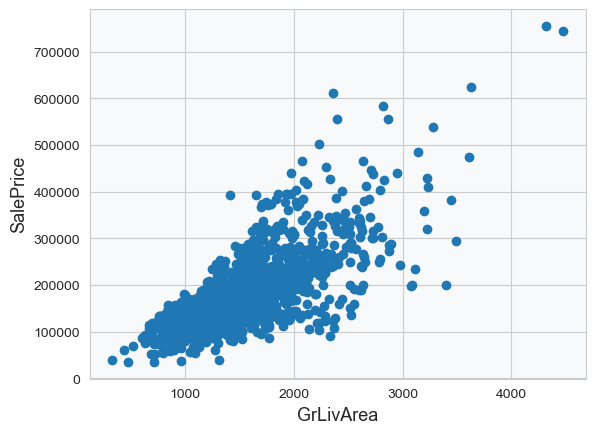

In [214]:

train = train_df.drop(train_df[(train_df['GrLivArea']>4000) & (train_df['SalePrice']<300000)].index)

#Check the graphic again
fig, ax = plt.subplots()
ax.scatter(train['GrLivArea'], train['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

In [215]:
print("Before:", train_df.shape)
train = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & 
                               (train_df['SalePrice'] < 300000)].index)
print("After:", train.shape)


Before: (1460, 80)
After: (1458, 80)


Trong train có dòng 524 và 1299 có thứ tự 4676 và 5642 của Gr. 184000 và 160000 của th SalePrice

In [216]:
ntrain=train_df.shape[0]
ntest=test_df.shape[0]
y_train=np.log1p(train_df['SalePrice'].values)
all_data=pd.concat((train_df,test_df)).reset_index(drop=True)
all_data.drop(['SalePrice'],axis=1,inplace=True)
print("all_data size is : {}".format(all_data.shape))

all_data size is : (2919, 79)


In [217]:
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_data.head(20)

,Missing Ratio
PoolQC,99.657417
MiscFeature,96.402878
Alley,93.216855
Fence,80.438506
MasVnrType,60.500171
FireplaceQu,48.646797
LotFrontage,16.649538
GarageQual,5.447071
GarageYrBlt,5.447071
GarageCond,5.447071


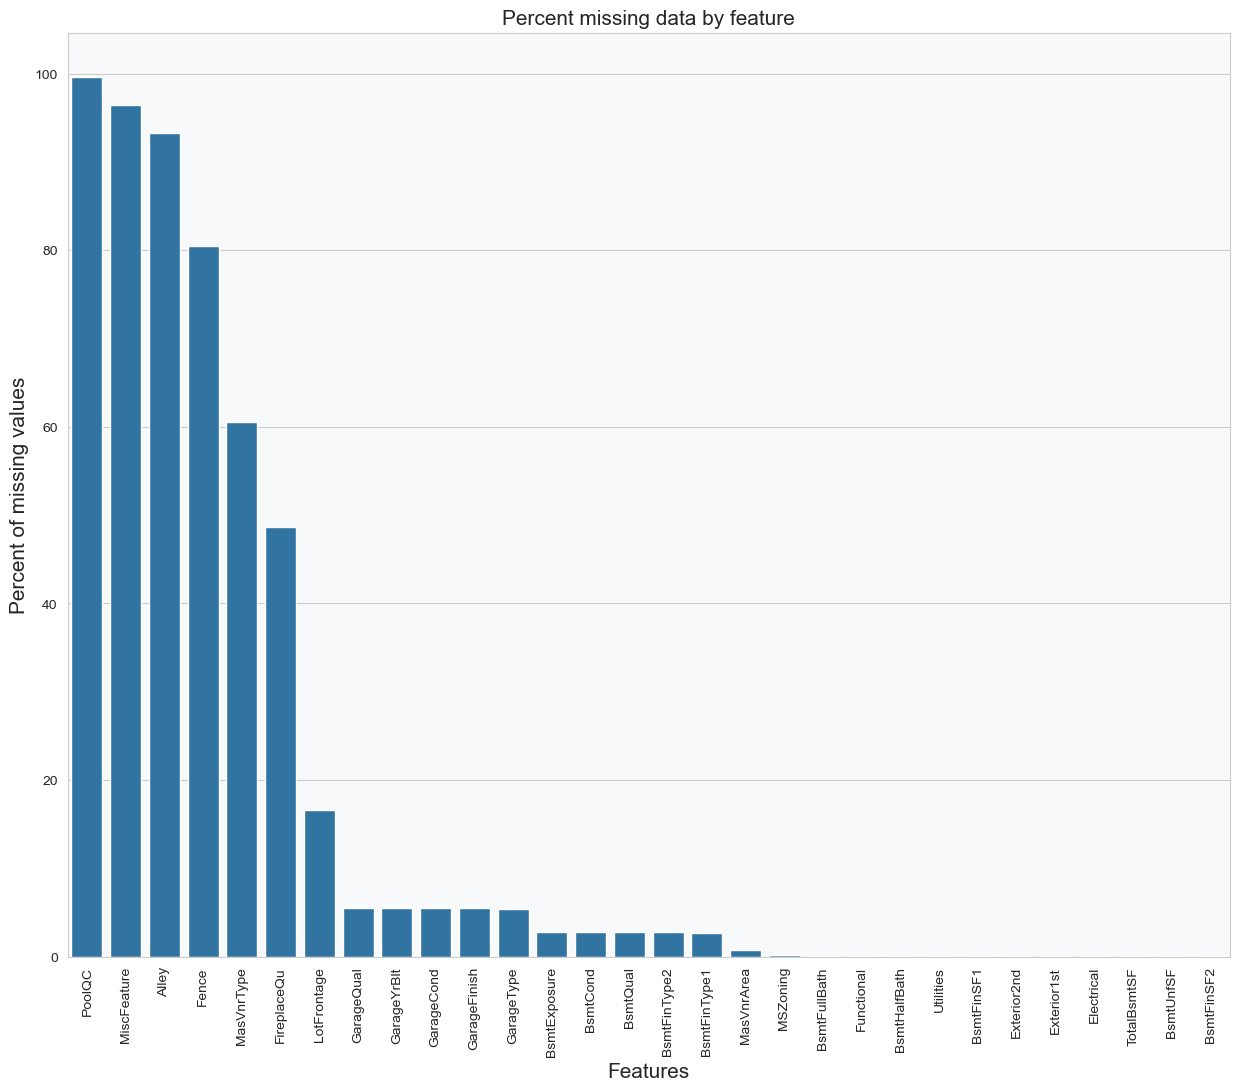

In [218]:
f, ax = plt.subplots(figsize=(15, 12))
plt.xticks(rotation=90)
sns.barplot(x=all_data_na.index, y=all_data_na)
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)
plt.show()

In [219]:
all_data['PoolQC']=all_data['PoolQC'].fillna('None')

In [220]:
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")

In [221]:
all_data["Alley"] = all_data["Alley"].fillna("None")

In [222]:
all_data["Fence"] = all_data["Fence"].fillna("None")

In [223]:
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")

In [224]:
#Group by neighborhood and fill in missing value by the median LotFrontage of all the neighborhood
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

In [225]:
for col in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    all_data[col] = all_data[col].fillna('None')

In [226]:
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    all_data[col] = all_data[col].fillna(0)

In [227]:
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

In [228]:
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')

In [229]:
all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)

In [230]:
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])

In [231]:
all_data = all_data.drop(['Utilities'], axis=1)

In [232]:
all_data["Functional"] = all_data["Functional"].fillna("Typ")

In [233]:
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

In [234]:
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])

In [235]:
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])

In [236]:
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])

In [237]:

all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")



In [238]:
#Check remaining missing values if any 
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :all_data_na})
print(missing_data)

Empty DataFrame
Columns: [Missing Ratio]
Index: []


In [239]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

def create_advanced_features(df):
    """
    Tạo features nâng cao dựa trên domain knowledge
    """
    print("🔧 ADVANCED FEATURE ENGINEERING")
    print("=" * 70)
    
    # ==========================================
    # 1. TIME-BASED FEATURES (IMPROVED)
    # ==========================================
    print("\n1️⃣ Enhanced Time Features...")
    
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    
    # Thêm: Is house new?
    df['IsNewHouse'] = (df['YearBuilt'] == df['YrSold']).astype(int)
    df['IsRecentlyRemodeled'] = (df['YearRemodAdd'] >= df['YrSold'] - 5).astype(int)
    
    # Thêm: Age bins
    df['AgeCategory'] = pd.cut(df['HouseAge'], 
                                bins=[0, 5, 10, 20, 50, 150],
                                labels=['Brand New', 'New', 'Young', 'Old', 'Very Old'])
    
    print(f"   ✅ Created 5 time-based features")
    
    # ==========================================
    # 2. AREA FEATURES (COMPREHENSIVE)
    # ==========================================
    print("\n2️⃣ Comprehensive Area Features...")
    
    # Total square footage
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # Total porch area
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + 
                           df['3SsnPorch'] + df['ScreenPorch'] + 
                           df['WoodDeckSF'])
    
    # Living area ratio
    df['LivingAreaRatio'] = df['GrLivArea'] / (df['TotalSF'] + 1)
    df['BsmtRatio'] = df['TotalBsmtSF'] / (df['TotalSF'] + 1)
    
    # Area per room
    df['TotalRooms'] = df['TotRmsAbvGrd'] + df['FullBath'] + df['HalfBath']
    df['AreaPerRoom'] = df['GrLivArea'] / (df['TotalRooms'] + 1)
    
    print(f"   ✅ Created 6 area-based features")
    
    # ==========================================
    # 3. QUALITY FEATURES (ADVANCED)
    # ==========================================
    print("\n3️⃣ Advanced Quality Features...")
    
    # Overall quality interactions
    df['QualityScore'] = (df['OverallQual'] + df['OverallCond']) / 2
    df['QualityArea'] = df['OverallQual'] * df['GrLivArea']
    df['QualityBath'] = df['OverallQual'] * (df['FullBath'] + 0.5*df['HalfBath'])
    
    # External quality
    quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'KitchenQual']
    if all(col in df.columns for col in quality_cols):
        # Encode nếu chưa encode
        from sklearn.preprocessing import LabelEncoder
        quality_sum = 0
        for col in quality_cols:
            if df[col].dtype == 'object':
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
            quality_sum += df[col]
        df['TotalQualityScore'] = quality_sum
    
    print(f"   ✅ Created 4 quality-based features")
    
    # ==========================================
    # 4. BATHROOM & BEDROOM FEATURES
    # ==========================================
    print("\n4️⃣ Bath & Bedroom Features...")
    
    df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] + 
                        df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    
    df['BathPerBedroom'] = df['TotalBath'] / (df['BedroomAbvGr'] + 1)
    df['HasMasterBath'] = (df['FullBath'] >= 2).astype(int)
    
    print(f"   ✅ Created 3 bath/bedroom features")
    
    # ==========================================
    # 5. BOOLEAN/BINARY FEATURES
    # ==========================================
    print("\n5️⃣ Boolean Features...")
    
    boolean_features = {
        'HasPool': df['PoolArea'] > 0,
        'Has2ndFloor': df['2ndFlrSF'] > 0,
        'HasGarage': df['GarageArea'] > 0,
        'HasBsmt': df['TotalBsmtSF'] > 0,
        'HasFireplace': df['Fireplaces'] > 0,
        'HasDeck': df['WoodDeckSF'] > 0,
        'HasPorch': df['TotalPorchSF'] > 0,
        'HasShed': df['MiscVal'] > 0
    }
    
    for name, condition in boolean_features.items():
        df[name] = condition.astype(int)
    
    print(f"   ✅ Created {len(boolean_features)} boolean features")
    
    # ==========================================
    # 6. NEIGHBORHOOD FEATURES (TARGET ENCODING PREP)
    # ==========================================
    print("\n6️⃣ Neighborhood Features...")
    
    # Neighborhood quality (sẽ được encode sau)
    neighborhood_features = {
        'Neighborhood_Rich': df['Neighborhood'].isin(['NoRidge', 'NridgHt', 'StoneBr']),
        'Neighborhood_Poor': df['Neighborhood'].isin(['MeadowV', 'IDOTRR', 'BrDale'])
    }
    
    for name, condition in neighborhood_features.items():
        df[name] = condition.astype(int)
    
    print(f"   ✅ Created 2 neighborhood features")
    
    # ==========================================
    # 7. POLYNOMIAL FEATURES (SELECTIVE)
    # ==========================================
    print("\n7️⃣ Polynomial Features (degree 2)...")
    
    # Chỉ dùng cho một số features quan trọng
    poly_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF']
    
    for feat in poly_features:
        if feat in df.columns:
            df[f'{feat}_squared'] = df[feat] ** 2
            df[f'{feat}_cubed'] = df[feat] ** 3
    
    print(f"   ✅ Created {len(poly_features)*2} polynomial features")
    
    # ==========================================
    # SUMMARY
    # ==========================================
    print("\n" + "=" * 70)
    print(f"📊 FEATURE ENGINEERING SUMMARY:")
    print(f"   • Original features: 79")
    print(f"   • New features: {df.shape[1] - 79}")
    print(f"   • Total features: {df.shape[1]}")
    
    return df

# === SỬ DỤNG ===
# Tạo features TRƯỚC KHI transform/encode
all_data = create_advanced_features(all_data)

🔧 ADVANCED FEATURE ENGINEERING

1️⃣ Enhanced Time Features...
   ✅ Created 5 time-based features

2️⃣ Comprehensive Area Features...
   ✅ Created 6 area-based features

3️⃣ Advanced Quality Features...
   ✅ Created 4 quality-based features

4️⃣ Bath & Bedroom Features...
   ✅ Created 3 bath/bedroom features

5️⃣ Boolean Features...
   ✅ Created 8 boolean features

6️⃣ Neighborhood Features...
   ✅ Created 2 neighborhood features

7️⃣ Polynomial Features (degree 2)...
   ✅ Created 6 polynomial features

📊 FEATURE ENGINEERING SUMMARY:
   • Original features: 79
   • New features: 33
   • Total features: 112


In [240]:
#MSSubClass=The building class
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)


#Changing OverallCond into a categorical variable
all_data['OverallCond'] = all_data['OverallCond'].astype(str)


#Year and month sold are transformed into categorical features.
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)



In [241]:
# # Cell mới: Xử lý outliers
# # Tương tự Top Kaggle solution

# # Remove extreme outliers (trước khi log transform)
# if 'SalePrice' in train_df.columns:
#     outliers_idx = train_df[(train_df['GrLivArea'] > 4000) & 
#                               (train_df['SalePrice'] < 300000)].index
#     if len(outliers_idx) > 0:
#         train_df = train_df.drop(outliers_idx)
#         print(f"✅ Removed {len(outliers_idx)} outliers")
#         print(f"New train shape: {train_df.shape}")

# # Log transform SalePrice để giảm skewness
# if 'SalePrice' in train_df.columns:
#     train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
#     print("✅ Applied log1p transformation to SalePrice")

In [242]:
from scipy.stats import skew
from scipy.special import boxcox1p

# Lấy numeric features (loại trừ cả object VÀ các cột đã convert sang string)
numeric_feats = all_data.select_dtypes(include=['int64', 'float64']).columns

# Tính skewness
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna()))
skewness_df = pd.DataFrame({'Skew': skewed_feats}).sort_values(by='Skew', ascending=False)

# Chọn features có |skew| > 0.5
threshold = 0.5
skewed_features = skewness_df[abs(skewness_df['Skew']) > threshold].index

print(f"Có {len(skewed_features)} features bị lệch (|skew| > {threshold})")
print(f"Top 10: {list(skewed_features[:10])}")

# Áp dụng Box-Cox transformation
lam = 0.15

for feat in skewed_features:
    if feat not in all_data.columns:
        continue
    
    # Kiểm tra giá trị <= 0
    if (all_data[feat] <= 0).any():
        # Dùng log1p nếu có giá trị âm/0
        all_data[feat] = np.log1p(all_data[feat] - all_data[feat].min() + 1)
        print(f"  📈 {feat}: log1p (có giá trị <= 0)")
    else:
        # Dùng Box-Cox nếu toàn dương
        all_data[feat] = boxcox1p(all_data[feat], lam)
        print(f"  📊 {feat}: boxcox1p")

print("\n✅ Hoàn tất xử lý skewed features!")

Có 56 features bị lệch (|skew| > 0.5)
Top 10: ['TotalBsmtSF_cubed', 'MiscVal', 'PoolArea', 'HasPool', 'LotArea', 'LowQualFinSF', '3SsnPorch', 'TotalBsmtSF_squared', 'GrLivArea_cubed', 'HasShed']
  📈 TotalBsmtSF_cubed: log1p (có giá trị <= 0)
  📈 MiscVal: log1p (có giá trị <= 0)
  📈 PoolArea: log1p (có giá trị <= 0)
  📈 HasPool: log1p (có giá trị <= 0)
  📊 LotArea: boxcox1p
  📈 LowQualFinSF: log1p (có giá trị <= 0)
  📈 3SsnPorch: log1p (có giá trị <= 0)
  📈 TotalBsmtSF_squared: log1p (có giá trị <= 0)
  📊 GrLivArea_cubed: boxcox1p
  📈 HasShed: log1p (có giá trị <= 0)
  📈 IsNewHouse: log1p (có giá trị <= 0)
  📈 KitchenAbvGr: log1p (có giá trị <= 0)
  📈 BsmtFinSF2: log1p (có giá trị <= 0)
  📈 EnclosedPorch: log1p (có giá trị <= 0)
  📊 GrLivArea_squared: boxcox1p
  📈 ScreenPorch: log1p (có giá trị <= 0)
  📈 BsmtHalfBath: log1p (có giá trị <= 0)
  📈 Neighborhood_Poor: log1p (có giá trị <= 0)
  📈 Neighborhood_Rich: log1p (có giá trị <= 0)
  📈 MasVnrArea: log1p (có giá trị <= 0)
  📈 OpenPorch

In [243]:
# from scipy.stats import skew
# from scipy.special import boxcox1p
# import numpy as np
# import pandas as pd

# # 1️⃣ Lấy danh sách các biến số (numeric features)
# numeric_feats = all_data.select_dtypes(exclude=["object"]).columns

# # 2️⃣ Tính độ lệch skewness cho từng biến
# skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
# skewness = pd.DataFrame({'Skew': skewed_feats})

# # 3️⃣ Chọn ra các biến có độ lệch đáng kể (|skew| > 0.5)
# threshold = 0.5
# skewed_features = skewness[abs(skewness['Skew']) > threshold].index  # FIX: Lấy đúng cột 'Skew'

# print(f"Có {len(skewed_features)} đặc trưng bị lệch phân phối sẽ được transform.\n")

# # 4️⃣ Áp dụng Box-Cox (hoặc log1p nếu có giá trị 0)
# lam = 0.15  # Lambda parameter cho Box-Cox

# for feat in skewed_features:
#     # Kiểm tra nếu có giá trị <= 0
#     if (all_data[feat] <= 0).any():
#         # Dùng log1p cho dữ liệu có giá trị âm hoặc 0
#         all_data[feat] = np.log1p(all_data[feat] + 1)  # FIX: Bỏ phần trừ min (gây lỗi)
#         print(f"  📈 {feat}: log1p (có giá trị <= 0)")
#     else:
#         # Box-Cox hoạt động tốt hơn nếu toàn dương
#         all_data[feat] = boxcox1p(all_data[feat], lam)
#         print(f"  📊 {feat}: boxcox1p")

# print("\n✅ Hoàn tất xử lý skewed features!")

In [244]:
# # === Detect outliers bằng IQR cho các features quan trọng ===

# num_cols = ['LotArea', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea']

# outlier_info = {}

# for col in num_cols:
#     data = all_data[col].dropna()
    
#     Q1 = data.quantile(0.25)
#     Q3 = data.quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
    
#     outliers = all_data[(all_data[col] < lower) | (all_data[col] > upper)]
    
#     outlier_info[col] = {
#         'count': len(outliers),
#         'percentage': len(outliers)/len(all_data)*100,
#         'lower': lower,
#         'upper': upper
#     }
    
#     print(f"📌 {col}: {len(outliers)} outliers ({len(outliers)/len(all_data)*100:.2f}%)")
#     # === Handle outliers: capping theo IQR ===

# for col in num_cols:
#     lower = outlier_info[col]['lower']
#     upper = outlier_info[col]['upper']
    
#     all_data[col] = np.where(all_data[col] < lower, lower, all_data[col])
#     all_data[col] = np.where(all_data[col] > upper, upper, all_data[col])
    
#     print(f"✅ {col} capped to [{lower:.2f}, {upper:.2f}]")
#     # Log transform để giảm skew (thường dùng trong bài Kaggle này)
# for col in ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF']:
#     all_data[col] = np.log1p(all_data[col])
#     print(f"📈 Applied log1p on {col}")




In [245]:
from sklearn.preprocessing import LabelEncoder

cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
                'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 
                'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 
                'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street', 
                'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold')


for col in cols:
    lbl = LabelEncoder()
    all_data[col] = lbl.fit_transform(all_data[col].astype(str))

print(f"✅ Label-encoded {len(cols)} columns")
print(f"📐 Shape all_data: {all_data.shape}")


✅ Label-encoded 26 columns
📐 Shape all_data: (2919, 112)


In [246]:


all_data = pd.get_dummies(all_data)
print(all_data.shape)
# one hot mấy thằng còn lại

(2919, 258)


In [247]:
# # Adding total sqfootage feature 
# all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
# all_data['TotalPorch'] = (
#     all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
#     all_data['3SsnPorch'] + all_data['ScreenPorch']
# )

# all_data['TotalArea'] = (
#     all_data['TotalBsmtSF'] + all_data['1stFlrSF'] +
#     all_data['2ndFlrSF'] + all_data['GarageArea']
# )

# all_data['YearsSinceRemodel'] = all_data['YrSold'] - all_data['YearRemodAdd']
# all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
# all_data['GrLivArea*Quality'] = all_data['GrLivArea'] * all_data['OverallQual']



### 🏠 Feature Engineering: Total Square Footage (`TotalSF`)

Giá nhà thường tỷ lệ thuận với **tổng diện tích sử dụng**.  
Thay vì chỉ dùng từng phần diện tích riêng lẻ, ta tạo feature:

\[
TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
\]

Mục đích:
- Gộp diện tích các tầng thành một biến tổng hợp mạnh hơn
- Giúp mô hình hiểu rõ mức độ lớn của căn nhà
- Là feature được sử dụng trong các model top Kaggle

```python
all_data['TotalSF'] = (
    all_data['TotalBsmtSF'] 
    + all_data['1stFlrSF'] 
    + all_data['2ndFlrSF']
)
```

Kỳ vọng: tăng khả năng dự đoán do tổng diện tích là yếu tố quan trọng nhất trong giá nhà.


In [248]:
# # Tạo đặc trưng TotalBath (tổng số phòng tắm quy đổi)
# all_data['TotalBath'] = (
#     all_data['FullBath'] +
#     0.5 * all_data['HalfBath'] +
#     all_data['BsmtFullBath'] +
#     0.5 * all_data['BsmtHalfBath']
# )


### 🛁 Feature Engineering: TotalBath (tổng phòng tắm quy đổi)

Các phòng tắm trong dữ liệu gồm:

- `FullBath` — phòng tắm đầy đủ
- `HalfBath` — phòng vệ sinh nhỏ (không có bồn tắm)
- `BsmtFullBath` — phòng tắm đầy đủ ở tầng hầm
- `BsmtHalfBath` — toilet ở tầng hầm

Để biểu diễn đúng giá trị sử dụng thực tế, ta quy đổi:

- Full Bath = 1
- Half Bath = 0.5

Công thức:

\[
TotalBath = FullBath + 0.5 \cdot HalfBath + BsmtFullBath + 0.5 \cdot BsmtHalfBath
\]

```python
all_data['TotalBath'] = (
    all_data['FullBath'] +
    0.5 * all_data['HalfBath'] +
    all_data['BsmtFullBath'] +
    0.5 * all_data['BsmtHalfBath']
)
```

Lợi ích:
- Tổng hợp thông tin phòng tắm → đặc trưng mạnh hơn
- Tăng hiệu quả dự đoán giá nhà


In [249]:
train = all_data[:ntrain]
test = all_data[ntrain:]


In [250]:
%pip install lightgbm

from sklearn.linear_model import ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [251]:
from sklearn.linear_model import LassoCV

lasso = make_pipeline(
    RobustScaler(),
    LassoCV(alphas=[0.0002, 0.0003, 0.0004], cv=10, random_state=1)
)


In [252]:
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0004, l1_ratio=.9, random_state=3))

In [253]:
KRR = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)

In [254]:
GBoost = GradientBoostingRegressor(
    n_estimators=3000,      # số cây (càng nhiều càng mạnh, tốn time)
    learning_rate=0.05,     # tốc độ học (nhỏ + nhiều cây = tốt hơn)
    max_depth=4,            # độ sâu mỗi cây (kiểm soát phức tạp)
    max_features='sqrt',    # số feature dùng mỗi lần split (giảm overfit)
    min_samples_leaf=15,    # số mẫu tối thiểu ở lá (chống noise)
    min_samples_split=10,   # mẫu tối thiểu để split node
    loss='huber',           # loss Huber = chống outlier tốt hơn MSE
    random_state=5
)


In [255]:
model_xgb = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.0004,
    reg_lambda=1
)




In [256]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=32,      # tăng độ phức tạp
    feature_fraction=0.6,
    bagging_fraction=0.6,
    bagging_freq=5,
    min_data_in_leaf=20,
    reg_alpha=0.1,      # L1
    reg_lambda=0.1      # L2
)


In [261]:
# === VALIDATION FUNCTION - PHIÊN BẢN CẢI TIẾN V2 ===

import warnings
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import time

def rmsle_cv(model, X=None, y=None, n_folds=5, verbose=True, return_time=False):
    """
    Cross-validation function nâng cao để đánh giá model bằng RMSLE.
    
    ✨ CẢI TIẾN:
    - Thêm timing để đo thời gian training
    - Xử lý warnings tự động
    - Thêm confidence interval (95%)
    - Return thêm training time nếu cần
    - Validation đầu vào chặt chẽ hơn
    
    Parameters:
    -----------
    model : estimator object
        Model cần đánh giá (phải có fit và predict methods)
    X : array-like, optional
        Features. Nếu None, dùng train.values
    y : array-like, optional  
        Target. Nếu None, dùng y_train
    n_folds : int, default=5
        Số lượng folds cho cross-validation
    verbose : bool, default=True
        In ra thông tin chi tiết
    return_time : bool, default=False
        Có trả về thời gian training không
        
    Returns:
    --------
    scores : ndarray
        Array chứa RMSE scores cho từng fold
    train_time : float (optional)
        Thời gian training (giây) nếu return_time=True
        
    Examples:
    ---------
    >>> scores = rmsle_cv(lasso)
    >>> scores, time_taken = rmsle_cv(lasso, return_time=True)
    """
    # ==========================================
    # VALIDATION ĐẦU VÀO
    # ==========================================
    if X is None:
        if 'train' not in globals():
            raise ValueError("❌ Biến 'train' không tồn tại. Vui lòng truyền X vào.")
        X = train.values
    
    if y is None:
        if 'y_train' not in globals():
            raise ValueError("❌ Biến 'y_train' không tồn tại. Vui lòng truyền y vào.")
        y = y_train
    
    # Check shape
    if len(X) != len(y):
        raise ValueError(f"❌ X và y có shape không khớp: {len(X)} vs {len(y)}")
    
    # ==========================================
    # CROSS-VALIDATION VỚI TIMING
    # ==========================================
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Suppress warnings khi training
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        start_time = time.time()
        
        # Tính cross-validation scores
        scores = np.sqrt(-cross_val_score(
            model, X, y, 
            scoring="neg_mean_squared_error", 
            cv=kf,
            n_jobs=-1
        ))
        
        elapsed_time = time.time() - start_time
    
    # ==========================================
    # TÍNH TOÁN THỐNG KÊ BỔ SUNG
    # ==========================================
    mean_score = scores.mean()
    std_score = scores.std()
    
    # 95% Confidence Interval
    ci_95 = 1.96 * (std_score / np.sqrt(n_folds))
    
    # Coefficient of Variation (CV%)
    cv_percent = (std_score / mean_score) * 100 if mean_score > 0 else 0
    
    # ==========================================
    # IN KẾT QUẢ CHI TIẾT
    # ==========================================
    if verbose:
        print(f"\n{'='*70}")
        print(f"📊 CROSS-VALIDATION RESULTS ({n_folds} folds)")
        print(f"{'='*70}")
        
        # Scores từng fold
        print(f"\n🔹 Scores per fold:")
        for i, score in enumerate(scores, 1):
            print(f"   Fold {i}: {score:.5f}")
        
        print(f"\n{'─'*70}")
        
        # Thống kê tổng quan
        print(f"📈 SUMMARY STATISTICS:")
        print(f"   • Mean RMSLE:  {mean_score:.5f}")
        print(f"   • Std RMSLE:   {std_score:.5f}")
        print(f"   • Min RMSLE:   {scores.min():.5f}")
        print(f"   • Max RMSLE:   {scores.max():.5f}")
        print(f"   • Range:       {scores.max() - scores.min():.5f}")
        
        print(f"\n{'─'*70}")
        
        # Confidence Interval
        print(f"📊 CONFIDENCE INTERVAL (95%):")
        print(f"   [{mean_score - ci_95:.5f}, {mean_score + ci_95:.5f}]")
        
        # Stability check
        print(f"\n🎯 MODEL STABILITY:")
        print(f"   • CV%: {cv_percent:.2f}%", end="")
        if cv_percent < 5:
            print(" ✅ (Very Stable)")
        elif cv_percent < 10:
            print(" ✅ (Stable)")
        elif cv_percent < 15:
            print(" ⚠️  (Moderate)")
        else:
            print(" ❌ (Unstable)")
        
        # Training time
        print(f"\n⏱️  TRAINING TIME:")
        print(f"   • Total: {elapsed_time:.2f}s")
        print(f"   • Per fold: {elapsed_time/n_folds:.2f}s")
        
        print(f"{'='*70}\n")
    
    # ==========================================
    # RETURN
    # ==========================================
    if return_time:
        return scores, elapsed_time
    return scores


# === HÀM BỔ SUNG: So sánh nhanh nhiều models ===

def quick_compare(models_dict, X=None, y=None, n_folds=5):
    """
    So sánh nhanh nhiều models (không in chi tiết từng model).
    
    Parameters:
    -----------
    models_dict : dict
        {'Model Name': model_object}
    X, y : array-like, optional
        Features và target
    n_folds : int
        Số folds
        
    Returns:
    --------
    results_df : DataFrame
        Bảng so sánh kết quả
    """
    import pandas as pd
    
    results = []
    total_start = time.time()
    
    print(f"\n{'='*70}")
    print(f"🔄 QUICK COMPARISON ({len(models_dict)} models)")
    print(f"{'='*70}\n")
    
    for name, model in models_dict.items():
        print(f"🎯 Training: {name:20s} ", end="", flush=True)
        
        # Training với timing
        scores, train_time = rmsle_cv(
            model, X, y, n_folds, 
            verbose=False, 
            return_time=True
        )
        
        results.append({
            'Model': name,
            'Mean_RMSLE': scores.mean(),
            'Std_RMSLE': scores.std(),
            'CV%': (scores.std() / scores.mean()) * 100,
            'Train_Time': train_time
        })
        
        print(f"✅ RMSLE: {scores.mean():.5f} (±{scores.std():.5f}) | {train_time:.1f}s")
    
    total_time = time.time() - total_start
    
    # Tạo DataFrame
    df = pd.DataFrame(results).sort_values('Mean_RMSLE')
    
    print(f"\n{'='*70}")
    print(f"📊 FINAL RANKING:")
    print(f"{'='*70}\n")
    print(df.to_string(index=False))
    
    # Best model
    best = df.iloc[0]
    print(f"\n{'='*70}")
    print(f"🏆 BEST MODEL: {best['Model']}")
    print(f"   • RMSLE: {best['Mean_RMSLE']:.5f} (±{best['Std_RMSLE']:.5f})")
    print(f"   • CV%: {best['CV%']:.2f}%")
    print(f"   • Time: {best['Train_Time']:.2f}s")
    print(f"\n⏱️  Total time: {total_time:.2f}s")
    print(f"{'='*70}\n")
    
    return df


# === SỬ DỤNG ===

# Cách 1: Đánh giá 1 model với timing
print("\n1️⃣ SINGLE MODEL EVALUATION:")
scores, train_time = rmsle_cv(lasso, return_time=True)

# Cách 2: So sánh nhanh nhiều models
print("\n2️⃣ BATCH COMPARISON:")
models = {
    'Lasso': lasso,
    'ElasticNet': ENet,
    'KernelRidge': KRR,
    'GradBoost': GBoost,
    'XGBoost': model_xgb,
    'LightGBM': model_lgb
}

results_df = quick_compare(models, n_folds=5)

# Lưu kết quả
results_df.to_csv('../notebooks/model_comparison_v2.csv', index=False)
print(f"💾 Saved to: ../notebooks/model_comparison_v2.csv")


1️⃣ SINGLE MODEL EVALUATION:

📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12431
   Fold 2: 0.11489
   Fold 3: 0.17705
   Fold 4: 0.12014
   Fold 5: 0.10484

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12825
   • Std RMSLE:   0.02525
   • Min RMSLE:   0.10484
   • Max RMSLE:   0.17705
   • Range:       0.07221

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10611, 0.15038]

🎯 MODEL STABILITY:
   • CV%: 19.69% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 6.95s
   • Per fold: 1.39s


2️⃣ BATCH COMPARISON:

🔄 QUICK COMPARISON (6 models)

🎯 Training: Lasso                ✅ RMSLE: 0.12825 (±0.02525) | 5.3s
🎯 Training: ElasticNet           ✅ RMSLE: 0.12839 (±0.02514) | 1.0s
🎯 Training: KernelRidge          ✅ RMSLE: 0.17927 (±0.04617) | 0.6s
🎯 Training: GradBoost            ✅ RMSLE: 0.12505 (±0.02047) | 17.9s
🎯 Training: XGBoost             

In [ ]:
score = rmsle_cv(lasso)
print("\nLasso score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

📊 Cross-Validation Results (5 folds):
   • Mean RMSLE: 0.1282
   • Std RMSLE:  0.0253

Lasso score: 0.1282 (0.0253)



In [262]:
score = rmsle_cv(ENet)
print("ElasticNet score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12392
   Fold 2: 0.11514
   Fold 3: 0.17711
   Fold 4: 0.12031
   Fold 5: 0.10548

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12839
   • Std RMSLE:   0.02514
   • Min RMSLE:   0.10548
   • Max RMSLE:   0.17711
   • Range:       0.07163

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10636, 0.15042]

🎯 MODEL STABILITY:
   • CV%: 19.58% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 0.67s
   • Per fold: 0.13s

ElasticNet score: 0.1284 (0.0251)



In [263]:
score = rmsle_cv(KRR)
print("Kernel Ridge score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.15318
   Fold 2: 0.16660
   Fold 3: 0.27007
   Fold 4: 0.16367
   Fold 5: 0.14283

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.17927
   • Std RMSLE:   0.04617
   • Min RMSLE:   0.14283
   • Max RMSLE:   0.27007
   • Range:       0.12724

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.13880, 0.21973]

🎯 MODEL STABILITY:
   • CV%: 25.75% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 0.46s
   • Per fold: 0.09s

Kernel Ridge score: 0.1793 (0.0462)



In [264]:
score = rmsle_cv(GBoost)
print("Gradient Boosting score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.13270
   Fold 2: 0.10593
   Fold 3: 0.16066
   Fold 4: 0.12042
   Fold 5: 0.10551

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12505
   • Std RMSLE:   0.02047
   • Min RMSLE:   0.10551
   • Max RMSLE:   0.16066
   • Range:       0.05515

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10710, 0.14299]

🎯 MODEL STABILITY:
   • CV%: 16.37% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 15.03s
   • Per fold: 3.01s

Gradient Boosting score: 0.1250 (0.0205)



In [265]:

score = rmsle_cv(model_xgb)
print("Xgboost score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.13195
   Fold 2: 0.10893
   Fold 3: 0.15599
   Fold 4: 0.11296
   Fold 5: 0.10449

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12286
   • Std RMSLE:   0.01903
   • Min RMSLE:   0.10449
   • Max RMSLE:   0.15599
   • Range:       0.05150

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10619, 0.13954]

🎯 MODEL STABILITY:
   • CV%: 15.49% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 5.73s
   • Per fold: 1.15s

Xgboost score: 0.1229 (0.0190)



In [266]:
score = rmsle_cv(model_lgb)
print("LGBM score: {:.4f} ({:.4f})\n" .format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.13553
   Fold 2: 0.11535
   Fold 3: 0.16527
   Fold 4: 0.12359
   Fold 5: 0.11512

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.13097
   • Std RMSLE:   0.01869
   • Min RMSLE:   0.11512
   • Max RMSLE:   0.16527
   • Range:       0.05015

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.11459, 0.14735]

🎯 MODEL STABILITY:
   • CV%: 14.27% ⚠️  (Moderate)

⏱️  TRAINING TIME:
   • Total: 51.26s
   • Per fold: 10.25s

LGBM score: 0.1310 (0.0187)



In [267]:
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
        
    # we define clones of the original models to fit the data in
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        
        # Train cloned base models
        for model in self.models_:
            model.fit(X, y)

        return self
    
    #Now we do the predictions for cloned models and average them
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)   

In [268]:
averaged_models = AveragingModels(models = (ENet, GBoost, KRR, lasso))

score = rmsle_cv(averaged_models)
print(" Averaged base models score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12345
   Fold 2: 0.11331
   Fold 3: 0.18825
   Fold 4: 0.11563
   Fold 5: 0.10341

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12881
   • Std RMSLE:   0.03040
   • Min RMSLE:   0.10341
   • Max RMSLE:   0.18825
   • Range:       0.08484

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10216, 0.15546]

🎯 MODEL STABILITY:
   • CV%: 23.60% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 19.56s
   • Per fold: 3.91s

 Averaged base models score: 0.1288 (0.0304)



In [269]:
class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
   
    # We again fit the data on clones of the original models
    def fit(self, X, y):
        self.base_models_ = [list() for x in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)
        
        # Train cloned base models then create out-of-fold predictions
        # that are needed to train the cloned meta-model
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_index, holdout_index in kfold.split(X, y):
                instance = clone(model)
                self.base_models_[i].append(instance)
                instance.fit(X[train_index], y[train_index])
                y_pred = instance.predict(X[holdout_index])
                out_of_fold_predictions[holdout_index, i] = y_pred
                
        # Now train the cloned  meta-model using the out-of-fold predictions as new feature
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self
   
    #Do the predictions of all base models on the test data and use the averaged predictions as 
    #meta-features for the final prediction which is done by the meta-model
    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_ ])
        return self.meta_model_.predict(meta_features)

In [270]:
stacked_averaged_models = StackingAveragedModels(base_models = (ENet, GBoost, KRR),
                                                 meta_model = lasso)

score = rmsle_cv(stacked_averaged_models)
print("Stacking Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))


📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12525
   Fold 2: 0.10389
   Fold 3: 0.17120
   Fold 4: 0.11476
   Fold 5: 0.10072

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12317
   • Std RMSLE:   0.02552
   • Min RMSLE:   0.10072
   • Max RMSLE:   0.17120
   • Range:       0.07048

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10079, 0.14554]

🎯 MODEL STABILITY:
   • CV%: 20.72% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 117.47s
   • Per fold: 23.49s

Stacking Averaged models score: 0.1232 (0.0255)


In [271]:
def rmsle(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

In [272]:

# 1. Stacking Model
print("\n1️⃣ Training Stacking Model...")
stacked_averaged_models.fit(train.values, y_train)
stacked_train_pred = stacked_averaged_models.predict(train.values)
stacked_pred = np.expm1(stacked_averaged_models.predict(test.values))
print(f"   ✅ Stacking RMSLE: {rmsle(y_train, stacked_train_pred):.4f}")



1️⃣ Training Stacking Model...
   ✅ Stacking RMSLE: 0.0802


In [273]:
print("\n2️⃣ Training XGBoost...")
model_xgb.fit(train.values, y_train)  # ✅ FIX: Dùng .values
xgb_train_pred = model_xgb.predict(train.values)  # ✅ FIX
xgb_pred = np.expm1(model_xgb.predict(test.values))  # ✅ FIX
print(f"   ✅ XGBoost RMSLE: {rmsle(y_train, xgb_train_pred):.4f}")



2️⃣ Training XGBoost...
   ✅ XGBoost RMSLE: 0.0209


In [274]:
# 3. LightGBM
print("\n3️⃣ Training LightGBM...")
model_lgb.fit(train.values, y_train)  # ✅ FIX: Dùng .values
lgb_train_pred = model_lgb.predict(train.values)  # ✅ FIX
lgb_pred = np.expm1(model_lgb.predict(test.values))  # ✅ FIX: Giữ nguyên
print(f"   ✅ LightGBM RMSLE: {rmsle(y_train, lgb_train_pred):.4f}")



3️⃣ Training LightGBM...
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing 

In [275]:
# === VALIDATION CHECK ===

print("\n📊 KIỂM TRA PREDICTIONS:")
print("=" * 50)

# Check shapes
print(f"✅ Stacking predictions shape: {stacked_pred.shape}")
print(f"✅ XGBoost predictions shape:  {xgb_pred.shape}")
print(f"✅ LightGBM predictions shape:  {lgb_pred.shape}")

# Check ranges (sau khi expm1)
print(f"\n💰 PRICE RANGES:")
print(f"   Stacking: [{stacked_pred.min():.0f}, {stacked_pred.max():.0f}]")
print(f"   XGBoost:  [{xgb_pred.min():.0f}, {xgb_pred.max():.0f}]")
print(f"   LightGBM: [{lgb_pred.min():.0f}, {lgb_pred.max():.0f}]")

# Check for NaN or Inf
print(f"\n🔍 CHECK NaN/Inf:")
print(f"   Stacking NaN: {np.isnan(stacked_pred).sum()}")
print(f"   XGBoost NaN:  {np.isnan(xgb_pred).sum()}")
print(f"   LightGBM NaN: {np.isnan(lgb_pred).sum()}")

# Training RMSLE
print(f"\n📈 TRAINING RMSLE:")
print(f"   Stacking: {rmsle(y_train, stacked_train_pred):.4f}")
print(f"   XGBoost:  {rmsle(y_train, xgb_train_pred):.4f}")
print(f"   LightGBM: {rmsle(y_train, lgb_train_pred):.4f}")

print("\n" + "=" * 50)


📊 KIỂM TRA PREDICTIONS:
✅ Stacking predictions shape: (1459,)
✅ XGBoost predictions shape:  (1459,)
✅ LightGBM predictions shape:  (1459,)

💰 PRICE RANGES:
   Stacking: [47678, 506947]
   XGBoost:  [37573, 538709]
   LightGBM: [47542, 517994]

🔍 CHECK NaN/Inf:
   Stacking NaN: 0
   XGBoost NaN:  0
   LightGBM NaN: 0

📈 TRAINING RMSLE:
   Stacking: 0.0802
   XGBoost:  0.0209
   LightGBM: 0.0153



In [276]:


# === HÀM BỔ SUNG: So sánh nhiều models ===

def compare_models(models_dict, X=None, y=None, n_folds=5):
    """
    So sánh hiệu suất của nhiều models.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionary với key là tên model, value là model object
        Ví dụ: {'Lasso': lasso, 'Ridge': ridge}
    X : array-like, optional
        Features
    y : array-like, optional
        Target
    n_folds : int, default=5
        Số lượng folds
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame chứa kết quả so sánh các models
    """
    results = []
    
    print("🔄 Bắt đầu so sánh models...")
    print("=" * 70)
    
    for name, model in models_dict.items():
        print(f"\n🎯 Đang đánh giá: {name}")
        scores = rmsle_cv(model, X, y, n_folds, verbose=False)
        
        results.append({
            'Model': name,
            'Mean_RMSLE': scores.mean(),
            'Std_RMSLE': scores.std(),
            'Min_RMSLE': scores.min(),
            'Max_RMSLE': scores.max()
        })
        
        print(f"   ✅ {name}: {scores.mean():.4f} (±{scores.std():.4f})")
    
    print("\n" + "=" * 70)
    
    # Tạo DataFrame và sắp xếp theo Mean_RMSLE
    results_df = pd.DataFrame(results).sort_values('Mean_RMSLE')
    
    print("\n📊 KẾT QUẢ SO SÁNH TỔNG QUAN:")
    print(results_df.to_string(index=False))
    
    # Tìm model tốt nhất
    best_model = results_df.iloc[0]
    print(f"\n🏆 MODEL TỐT NHẤT: {best_model['Model']}")
    print(f"   • RMSLE: {best_model['Mean_RMSLE']:.4f} (±{best_model['Std_RMSLE']:.4f})")
    
    return results_df


# === SỬ DỤNG ===

# Cách 1: Đánh giá từng model (giống cũ)
print("\n" + "="*70)
print("1️⃣ ĐÁNH GIÁ LASSO")
print("="*70)
score = rmsle_cv(lasso)

print("\n" + "="*70)
print("2️⃣ ĐÁNH GIÁ ELASTICNET")
print("="*70)
score = rmsle_cv(ENet)

# Cách 2: So sánh tất cả models cùng lúc
print("\n" + "="*70)
print("🔍 SO SÁNH TẤT CẢ MODELS")
print("="*70)

models_comparison = {
    'Lasso': lasso,
    'ElasticNet': ENet,
    'Kernel Ridge': KRR,
    'Gradient Boosting': GBoost,
    'XGBoost': model_xgb,
    'LightGBM': model_lgb
}

results_df = compare_models(models_comparison, n_folds=5)

# Lưu kết quả
results_df.to_csv('../notebooks/model_comparison.csv', index=False)
print("\n💾 Đã lưu kết quả vào: ../output/model_comparison.csv")


1️⃣ ĐÁNH GIÁ LASSO

📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12431
   Fold 2: 0.11489
   Fold 3: 0.17705
   Fold 4: 0.12014
   Fold 5: 0.10484

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12825
   • Std RMSLE:   0.02525
   • Min RMSLE:   0.10484
   • Max RMSLE:   0.17705
   • Range:       0.07221

──────────────────────────────────────────────────────────────────────
📊 CONFIDENCE INTERVAL (95%):
   [0.10611, 0.15038]

🎯 MODEL STABILITY:
   • CV%: 19.69% ❌ (Unstable)

⏱️  TRAINING TIME:
   • Total: 3.26s
   • Per fold: 0.65s


2️⃣ ĐÁNH GIÁ ELASTICNET

📊 CROSS-VALIDATION RESULTS (5 folds)

🔹 Scores per fold:
   Fold 1: 0.12392
   Fold 2: 0.11514
   Fold 3: 0.17711
   Fold 4: 0.12031
   Fold 5: 0.10548

──────────────────────────────────────────────────────────────────────
📈 SUMMARY STATISTICS:
   • Mean RMSLE:  0.12839
   • Std RMSLE:   0.02514
   • Min RMSLE:   0.10548
   • Max RMSLE:   0.

In [ ]:
# import numpy as np
# from sklearn.metrics import mean_squared_log_error

# def rmsle(y, y_pred):
#     return np.sqrt(mean_squared_log_error(y, y_pred))

# best_score = float('inf')
# best_weights = None

# for w1 in np.arange(0.5, 0.9, 0.05):
#     for w2 in np.arange(0.05, 0.3, 0.05):
#         w3 = 1 - w1 - w2
#         if w3 < 0: continue
#         blend = w1*stacked_pred + w2*xgb_pred + w3*lgb_pred
#         score = rmsle(y_valid, blend)
#         if score < best_score:
#             best_score = score
#             best_weights = (w1, w2, w3)

# print("Best weights:", best_weights, "Best RMSLE:", best_score)


In [277]:
'''RMSE on the entire Train data when averaging'''

print('RMSLE score on train data:')
print(rmsle(y_train,stacked_train_pred*0.70 +
               xgb_train_pred*0.15 + lgb_train_pred*0.15 ))

RMSLE score on train data:
0.059898617873724753


In [278]:
ensemble = stacked_pred*0.70 + xgb_pred*0.15 + lgb_pred*0.15

In [279]:
sub = pd.DataFrame()
sub['Id'] = test_ID
sub['SalePrice'] = ensemble
sub.to_csv('submission.csv',index=False)